In [ ]:
# Extremal Distribution Gen
# "SO goes to RO through DRO"



Si $\Xi$ es convexo cerrado, $l(\xi)=\max_{k\leq K}l_k(\xi)$ dónde $-l_k$ son propias, semicontinuas inferiormente para todo $k\leq K$, $\exists\xi\in\Xi:l_k(\xi)>-\infty\forall k$ entonces

\begin{align}
\sup_{\mathbb Q\in\mathcal P_\epsilon} \mathbb E_{\mathbb Q}[l(\xi)]\\
\rightarrow
\end{align}

Se puede reformular exactamente en el dual convexo. 
$ sup_{a_{ik},q_{ik}} \sum\sum$

$\text{s.t.}~~stuff$

Si $\Xi$ es compacto o $l(\xi)$ es concava entonces la distribución de peor caso existe y es discreta.

(25, 2)
Restricted license - for non-production use only - expires 2025-11-24
2
Iterating
last eps: 10.0
0.01
0.010722672220103232
0.011497569953977356
0.012328467394420659
0.013219411484660288
0.014174741629268055
0.01519911082952934
0.016297508346206444
0.01747528400007684
0.01873817422860384
0.02009233002565047
0.021544346900318846
0.023101297000831605
0.024770763559917114
0.026560877829466867
0.02848035868435802
0.030538555088334154
0.03274549162877728
0.03511191734215131
0.037649358067924674
0.040370172585965536
0.04328761281083057
0.046415888336127795
0.049770235643321115
0.0533669923120631
0.05722367659350217
0.06135907273413173
0.06579332246575682
0.07054802310718646
0.07564633275546291
0.08111308307896872
0.08697490026177834
0.093260334688322
0.1
0.10722672220103231
0.11497569953977356
0.12328467394420659
0.13219411484660293
0.14174741629268056
0.1519911082952934
0.16297508346206444
0.17475284000076838
0.1873817422860384
0.20092330025650468
0.21544346900318845
0.23101297000831

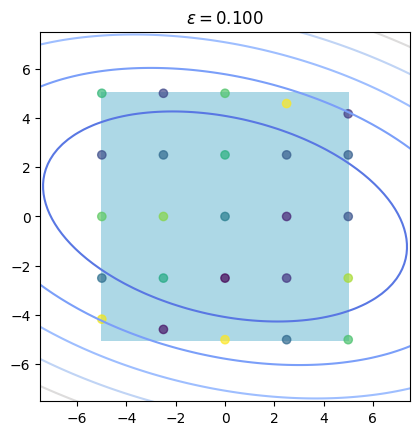

In [ ]:
#with mosek fusion

import numpy as np
import gurobipy as gp
from gurobipy import GRB

# Parámetros de la función cuadrática
a = 1
b = 3
c = 1
Q=-np.array([[a,c/2],[c/2,b]])
#C*xi<=d
bound=5
L=5
N=L*L

# Cuadrado
C=np.array([[1,0],[-1,0],[0,1],[0,-1]])
d=1.01*bound*np.ones((4,1))
x1n = np.linspace(-bound, bound, L)
x2n = np.linspace(-bound, bound, L)
X1g, X2g = np.meshgrid(x1n, x2n)
Xhat = np.stack([X1g.ravel(), X2g.ravel()], axis=1)  # shape (N, 2)

# Rombo
# C=np.array([[1,1],[1,-1],[-1,1],[-1,-1]])
# d=1.01*bound*np.ones((4,1))
# x1n = np.linspace(-bound, bound, int(np.ceil(L*1)))
# x2n = np.linspace(-bound, bound, int(np.rint(L*1)))
# X1g, X2g = np.meshgrid(x1n, x2n)
# Xhat = np.stack([X1g.ravel(), X2g.ravel()], axis=1)  # shape (N, 2)
# mask = np.all(C@Xhat.T<=d,axis=0)
# Xhat = Xhat[mask]
# N=Xhat.shape[0]

print(Xhat.shape)

# Get Qwc one time
eps=0.1
M=gp.Model(f"WC_dist_r{eps}")
q=M.addMVar(shape=(N,2),name="q",vtype=GRB.CONTINUOUS,lb=-GRB.INFINITY)
qabs=M.addMVar(shape=(N,2),name="qnorm",vtype=GRB.CONTINUOUS,lb=0.0)
# xhat=M.addMVar(shape=(N,2),name="xhat",vtype=GRB.CONTINUOUS)
# M.addConstrs((Xhat[i,:]==Xhat[i,:] for i in range(N)),name="xhatc")
xi_q=gp.LinExpr()
xi_q=Xhat-q
# Función cuadrática: f(x1,x2)=x@Q@x=a*x1^2+b*x2^2+c*x_1*x_2
# lxi_q=a*xi_q[:,0]*xi_q[:,0] + b*xi_q[:,1]*xi_q[:,1] + c*xi_q[:,0]*xi_q[:,1]
fobj=gp.QuadExpr()
for i in range(N):
    fobj+=xi_q[i,:]@Q@xi_q[i,:]    
M.setObjective(fobj.sum()/N,GRB.MAXIMIZE)
M.addConstrs((qabs[i,j]==gp.abs_(q[i,j]) for j in [0,1] for i in range(N)),name="norm")
# for i in range(N):
#     M.addGenConstrNorm(qnorm[i],q[i,:],1.0,name=f"norm_{i}") #L1 norm
radius=M.addConstr(qabs.sum()/N<=eps,name="radius")
M.addConstrs((C@xi_q[i,:]<=d for i in range(N)),name="support") #C*(xihat_i-q_i)<=d
M.params.LogToConsole=False
M.optimize()
print(M.Status) #1=Loaded,2=Optimal,3=Infeasible,4=Inf/Unbounded,5=Unbounded 
Qwc=Xhat-q.X
# print(f"eps={eps}\n",Qwc)

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

fig, ax = plt.subplots()
# Rombo
# coords = 1.01*np.array([[ 0,  bound],[ bound, 0],[ 0, -bound],[-bound, 0]])
# Cuadrado
coords = 1.01*np.array([[bound,bound],[-bound,bound],[-bound,-bound],[bound,-bound]])

patch = Polygon(coords, closed=True, facecolor='lightblue', edgecolor='none', zorder=0)
ax.add_patch(patch)

# Función cuadrática: f(x1, x2) =x@Q@x= ax1^2 + b x2^2 +c x_1 x_2
x1 = np.linspace(-2*bound, 2*bound, 100)
x2 = np.linspace(-2*bound, 2*bound, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = a * X1**2 + b * X2**2 + c*X1*X2
contours = ax.contour(X1, X2, Z, levels=10, cmap='coolwarm')
colors=np.random.rand(N)
dots=ax.scatter(Qwc[:,0], Qwc[:,1], c=colors, cmap='viridis',alpha=0.7)
ax.set_xlim(-1.5*bound, 1.5*bound)
ax.set_ylim(-1.5*bound, 1.5*bound)
title=ax.set_title(rf"$\varepsilon = {eps:,.3f}$")
ax.set_aspect('equal')
# plt.tight_layout()
# plt.show()

#Iterate Qwc program
print("Iterating")
Niter=100
epsvec=np.logspace(-2,1,Niter)
print(f"last eps: {epsvec[-1]}")
Qwc_big=np.zeros((Niter,N,2))

M.objv

#Retrieve solutions
for i in range(Niter):
    print(epsvec[i])
    radius.RHS=epsvec[i]
    if(epsvec[i]>0.5):
        p=M.presolve()
        # p.optimize()
        print(f"presolved, Stat: {p.Status}")
    M.optimize()
    if not (M.Status==GRB.OPTIMAL): print("zzz")
    Qwc_big[i,:,:]=Xhat-q.X

In [ ]:
with open('drowdual/Qwc_out.npy','rb') as f:
    # np.save(f,Qwc_big)
    # a=np.load(f)
    # print(a.shape)

(100, 13, 2)


Animating
0.01
0.030538555088334154
0.1
0.24770763559917114
0.30538555088334157
0.533669923120631
0.7054802310718645
0.8697490026177834
1.232846739442066
1.7475284000076847
2.0092330025650478
2.4770763559917115
2.848035868435802
3.2745491628777286
4.037017258596554
4.328761281083057
4.9770235643321135
6.135907273413176


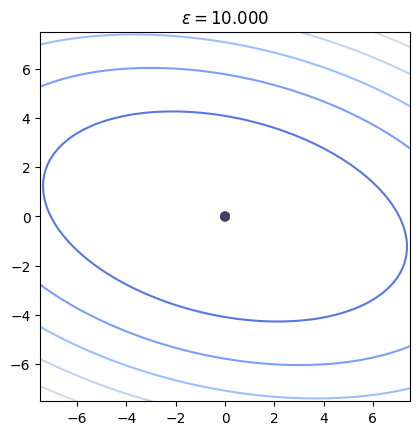

In [ ]:
fig, ax = plt.subplots()
patch = Polygon(coords, closed=True, facecolor='lightblue', edgecolor='none', zorder=0)
# ax.add_patch(patch)
contours = ax.contour(X1, X2, Z, levels=10, cmap='coolwarm')
colors=np.random.rand(N)
dots=ax.scatter(Qwc[:,0], Qwc[:,1], c=colors, cmap='viridis',alpha=0.7)
ax.set_xlim(-1.5*bound, 1.5*bound)
ax.set_ylim(-1.5*bound, 1.5*bound)
title=ax.set_title(rf"$\varepsilon = {eps:,.3f}$")
ax.set_aspect('equal')


#Animate
print("Animating")
title.set_text(rf"$\varepsilon = {epsvec[0]:,.3f}$")
def update(frame):
    dots.set_offsets(Qwc_big[frame,:,:])
    dots.set_array(colors)
    title.set_text(rf"$\varepsilon = {epsvec[frame]:,.3f}$")
    return dots,title
dur=5#sec
ani = FuncAnimation(fig, update, frames=Niter, interval=5000/Niter, blit=True)
# ani.save("drowdual/DROWdual_inside_nosq.gif",writer=PillowWriter(fps=Niter/5))

#save idk 4 images
seleps=np.array([0.01,0.03,0.1,0.24,0.3,0.55,0.7,0.9,1.2,1.7,2,2.4,2.8,3.2,4,4.2,5,6])
for i in range(len(seleps)):
    idx=np.abs(epsvec-seleps[i]).argmin()
    print(epsvec[idx])
    dots.set_offsets(Qwc_big[idx,:,:])
    dots.set_array(colors)
    title.set_text(rf"$\varepsilon = {epsvec[idx]:,.3f}$")
    # plt.savefig(f"drowdual/DROWdual_in_nosq_{i}.png",format='png')
# for i, data in enumerate()
HTML(ani.to_jshtml())

In [ ]:
# import mosek.fusion as fs
# import mosek.fusion.pythonic

# elif ENGINE=="MOSEK":
#     #Slow ass piece of shit
#     M=fs.Model(f"WC_dist_r{eps}")
#     q=M.variable('q',[N,2],fs.Domain.unbounded())
#     qnorm=M.variable('q',N,fs.Domain.unbounded())
#     xi_q=Xhat-q
#     #M.constraint()

#     #WCexp=a*(xi_q[:,1])*(xi_q[:,1])

#     WCexp=fs.Expr.sum( a*(xi_q[:,1])^2 + b*(xi_q[:,2])^2 - c*(xi_q[:,1])*(xi_q[:,2]) )/N #()=xihat-qi
#     M.objective("WCexp",fs.ObjectiveSense.Maximize,)
#     if linear objective you can write as c.T @ x or x.T @ c, you can index matrix row as A[i]

#     M.solve()
#  qopt=q.level()

<>:54: SyntaxWarning: invalid escape sequence '\s'
<>:54: SyntaxWarning: invalid escape sequence '\s'
C:\Users\seleg\AppData\Local\Temp\ipykernel_26836\1998169570.py:54: SyntaxWarning: invalid escape sequence '\s'
  x_tick_labels = [f"$\sum_{{i=1}}^{i+1}p_i$" for i in range(len(energia_acumulada))]


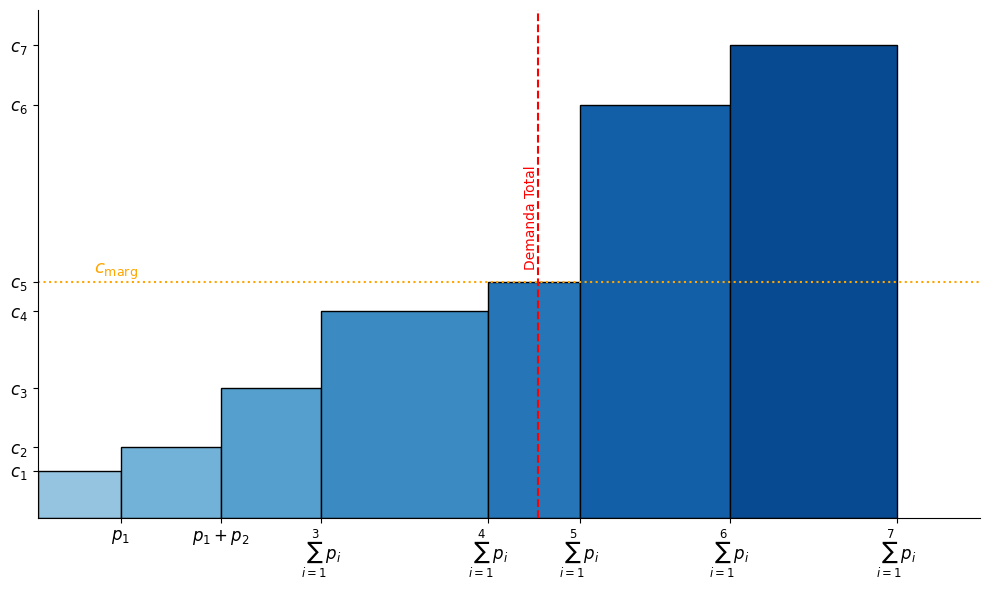

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Datos de ejemplo
costos = np.array([80, 120, 220, 350, 400, 700, 800])
energias = np.array([100, 120, 120, 200, 110, 180, 200])
demanda = 600
n=len(costos)
# Ordenar por precio
orden = np.argsort(costos)
costos = costos[orden]
energias = energias[orden]

# Energía acumulada
energia_acumulada = np.cumsum(energias)
energia_inicio = np.insert(energia_acumulada[:-1], 0, 0)

# Colores por barra
colores = cm.Blues(np.linspace(0.4, 0.9, n))

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar barras verticales
for i in range(n):
    ax.bar(
        x=energia_inicio[i], height=costos[i],
        width=energias[i], align='edge',
        color=colores[i], edgecolor='black'
    )

# Precio marginal
for i in range(len(energia_acumulada)):
    if demanda <= energia_acumulada[i]:
        c_marg = costos[i]
        break

# Línea vertical de demanda
ax.axvline(x=demanda, color='red', linestyle='--', linewidth=1.5)
ax.text(demanda,c_marg+20,"Demanda Total",color='red',fontsize=10,va='bottom',ha='right',rotation='vertical')

# Línea horizontal de precio marginal
ax.axhline(y=c_marg, color='orange', linestyle=':', linewidth=1.5)
ax.text(
    energia_acumulada[0] + 20, c_marg,
    r"$c_\mathrm{marg}$", color='orange', fontsize=13,
    va='bottom', ha='right'
)

# Etiquetas X: p_1, p_1 + p_2, ...
x_tick_positions = energia_acumulada
if (n>4):
    x_tick_labels = [f"$\sum_{{i=1}}^{i+1}p_i$" for i in range(len(energia_acumulada))]
    x_tick_labels[0]=f"$p_1$"
    x_tick_labels[1]=f"$p_1+p_2$"
else:
    x_tick_labels = [f"${' + '.join([f'p_{{{j+1}}}' for j in range(i+1)])}$" for i in range(len(energia_acumulada))]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, fontsize=12)

# Etiquetas Y: c_1, c_2, ...
y_tick_positions = costos
y_tick_labels = [f"$c_{{{i+1}}}$" for i in range(n)]
ax.set_yticks(y_tick_positions)
ax.set_yticklabels(y_tick_labels, fontsize=12)

# Mostrar ejes visibles (sin valores numéricos)
ax.spines[['bottom', 'left']].set_visible(True)
ax.spines[['top', 'right']].set_visible(False)

# Estética general
ax.set_xlim(0, energia_acumulada[-1] + 100)
ax.set_ylim(0, max(costos) + 60)
#ax.set_title("Curva de mérito - Despacho económico simple", fontsize=14)

plt.tight_layout()
plt.show()
